# Step 3: Visualisierung der Produktions-KPIs

Ziel: Die zentralen KPIs visuell darstellen, um Unterschiede zwischen Produktionslinien und Schichten schnell zu erkennen.

**Visualisiert werden:**
- Ausschussquote (%) nach Produktionslinie
- Stillstandsanteil (%) nach Schicht
- Energieverbrauch pro Stück (kWh) nach Produktionslinie
- Optional: Trend der Ausschussquote über die Zeit

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Daten laden

df = pd.read_csv("../data/produktionsdaten_premium_5Jahre.csv")

# Datum konvertieren

if "Datum" in df.columns:
    df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")

df.head()

,Datum,Unternehmen,Produkt,Modifikation,Produktionslinie,Schicht,Stueckzahl,Ausschuss,Betriebsstunden,Stillstandszeit_Min,...,Durchschnittstemperatur,Softwareversion,Firmwareversion,EndOfLine_Test,Materialkosten,Energieverbrauch_kWh,Auftragsnummer,Status,Fehlercode,Mitarbeiter_Produktion
0,2019-01-01,Industrium GmbH,HMI-Terminal,HMI-10,Linie 3,Nacht,37,2,5.7,22,...,54.3,v4.9,f1.0,Bestanden,4947.15,7.09,A-24944,in Produktion,I/O_ERROR,90
1,2019-01-01,Industrium GmbH,Robust Panel PC,RPPC-1100,Linie 3,Früh,59,4,5.7,48,...,56.9,v1.4,f3.1,Bestanden,4364.21,13.21,A-92508,in Produktion,POWER_FAIL,90
2,2019-01-01,ControlWare KG,Embedded Box PC,EPC-30,Linie 4,Nacht,298,14,4.4,43,...,70.3,v1.6,f2.3,Bestanden,3722.95,22.41,A-30839,pausiert,TEMP_HIGH,75
3,2019-01-01,NextFactory Solutions,Embedded Box PC,EPC-35,Linie 2,Nacht,288,24,7.6,44,...,60.6,v4.1,f3.3,Bestanden,3410.23,20.99,A-15474,pausiert,POWER_FAIL,110
4,2019-01-01,NextFactory Solutions,Edge Controller,EC-200,Linie 3,Nacht,285,4,9.4,57,...,43.6,v3.1,f2.3,Bestanden,9948.61,21.70,A-44437,in Produktion,POWER_FAIL,110


In [3]:
# KPI-Berechnungen (notwendig für Visualisierung)

df["Ausschussquote"] = (df["Ausschuss"] / df["Stueckzahl"]) * 100
df["Energie_pro_Stueck"] = df["Energieverbrauch_kWh"] / df["Stueckzahl"]
df["Stillstandsanteil"] = (df["Stillstandszeit_Min"] / (df["Betriebsstunden"] * 60)) * 100

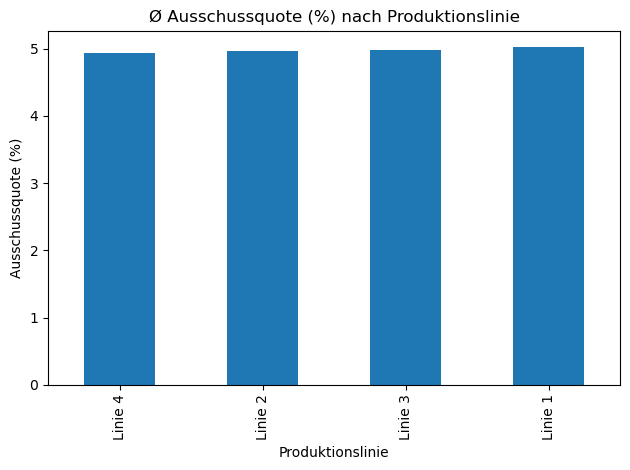

In [4]:
# Ausschussquote nach Produktionslinie

ausschuss_linie = (
    df.groupby("Produktionslinie")["Ausschussquote"]
    .mean()
    .sort_values()
)

ausschuss_linie.plot(kind="bar", title="Ø Ausschussquote (%) nach Produktionslinie")
plt.ylabel("Ausschussquote (%)")
plt.tight_layout()
plt.show()

### Fachliche Interpretation – Ausschussquote nach Produktionslinie

Die durchschnittliche Ausschussquote unterscheidet sich zwischen den einzelnen
Produktionslinien. Dies deutet darauf hin, dass die Prozessstabilität nicht
auf allen Linien gleich ausgeprägt ist.

Erhöhte Ausschussquoten können auf technische Probleme, Unterschiede in der
Maschinenkonfiguration, Materialqualität oder auf einen unterschiedlichen
Schulungsstand der Mitarbeitenden hinweisen.

Diese Kennzahl eignet sich besonders zur Identifikation von
Qualitätsproblemen und zur Priorisierung von Verbesserungsmaßnahmen.


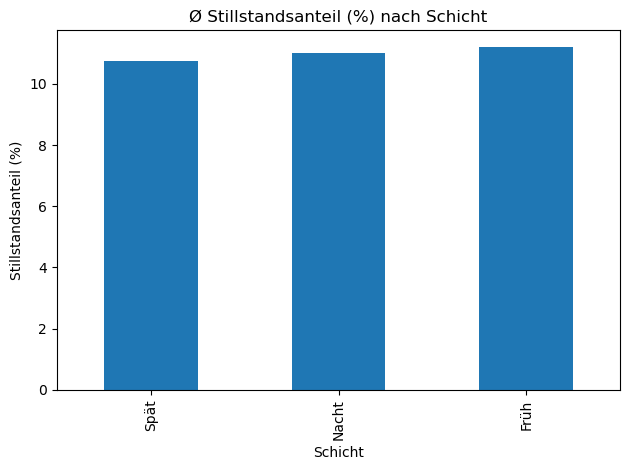

In [5]:
# Stillstandsanteil nach Schicht

stillstand_schicht = (
    df.groupby("Schicht")["Stillstandsanteil"]
    .mean()
    .sort_values()
)

stillstand_schicht.plot(
    kind="bar",
    title="Ø Stillstandsanteil (%) nach Schicht"
)

plt.ylabel("Stillstandsanteil (%)")
plt.tight_layout()
plt.show()


### Fachliche Interpretation – Stillstandsanteil nach Schicht

Der Stillstandsanteil variiert zwischen den einzelnen Schichten.
Dies weist auf schichtabhängige Unterschiede im Produktionsablauf hin.

Mögliche Ursachen können organisatorische Faktoren wie Schichtübergaben,
unterschiedliche Wartungszeiten oder Personalverfügbarkeit sein.

Die Analyse des Stillstandsanteils unterstützt dabei, organisatorische
Optimierungspotenziale zu identifizieren und die Anlagenverfügbarkeit zu erhöhen.


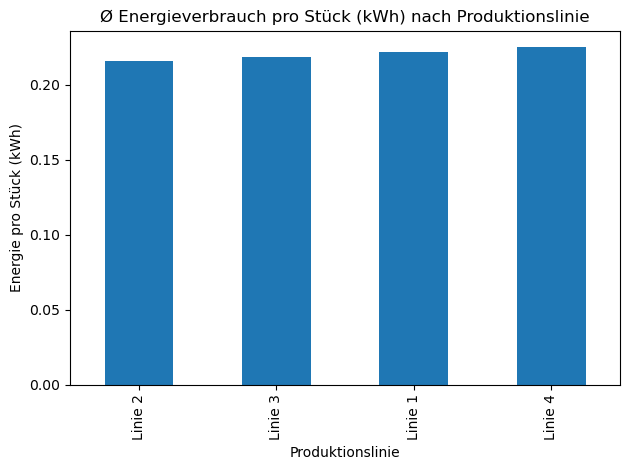

In [6]:
# Energieverbrauch pro Stück nach Produktionslinie

energie_linie = (
    df.groupby("Produktionslinie")["Energie_pro_Stueck"]
    .mean()
    .sort_values()
)

energie_linie.plot(
    kind="bar",
    title="Ø Energieverbrauch pro Stück (kWh) nach Produktionslinie"
)

plt.ylabel("Energie pro Stück (kWh)")
plt.tight_layout()
plt.show()


### Fachliche Interpretation – Energieverbrauch pro Stück

Der Energieverbrauch pro produziertem Stück unterscheidet sich zwischen den
Produktionslinien. Dies deutet auf unterschiedliche Energieeffizienzen hin.

Produktionslinien mit höherem Energieverbrauch pro Stück bieten
Einsparpotenziale, beispielsweise durch technische Optimierungen,
effizientere Maschinen oder verbesserte Prozesssteuerung.

Diese Kennzahl ist besonders relevant im Kontext von Kostenreduktion
und nachhaltiger Produktion.


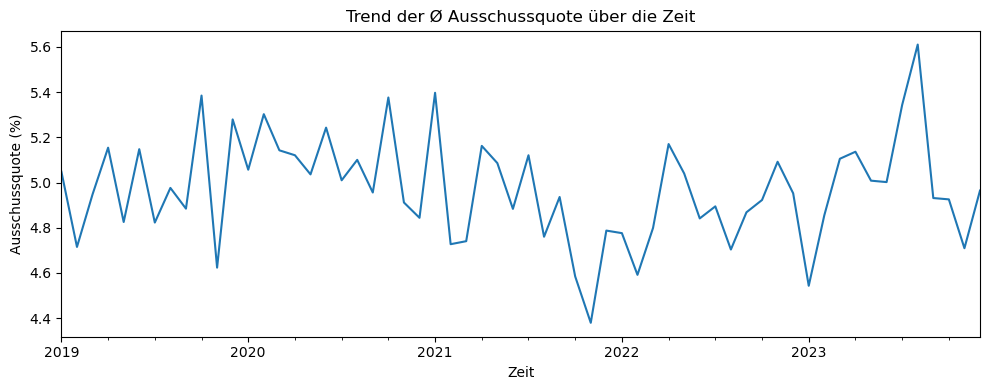

In [7]:
# Zeitlicher Trend der Ausschussquote

ausschuss_trend = (
    df.groupby(df["Datum"].dt.to_period("M"))["Ausschussquote"]
    .mean()
)

ausschuss_trend.plot(
    title="Trend der Ø Ausschussquote über die Zeit",
    figsize=(10, 4)
)

plt.ylabel("Ausschussquote (%)")
plt.xlabel("Zeit")
plt.tight_layout()
plt.show()


### Fachliche Interpretation – Zeitlicher Trend der Ausschussquote

Der zeitliche Verlauf der Ausschussquote zeigt, ob sich die
Produktqualität über den betrachteten Zeitraum verbessert oder verschlechtert hat.

Stabile oder sinkende Werte deuten auf einen kontrollierten und stabilen
Produktionsprozess hin. Ansteigende Trends können auf zunehmende
Verschleißerscheinungen oder Prozessabweichungen hindeuten.

Diese Analyse eignet sich zur Bewertung langfristiger Prozessstabilität.


## Gesamtfazit

Die Analyse der Produktionsdaten zeigt insgesamt einen stabilen,
aber nicht vollständig homogenen Produktionsprozess.

Zwischen den einzelnen Produktionslinien und Schichten bestehen
messbare Unterschiede in Ausschussquote, Stillstandsanteil und
Energieverbrauch pro Stück.

Besonders die Visualisierung der KPIs ermöglicht eine schnelle
Identifikation von Linien und Schichten mit erhöhtem
Optimierungspotenzial.

Die Ergebnisse bilden eine fundierte Grundlage für weiterführende
Maßnahmen, z. B.:
- gezielte Qualitätsverbesserungen
- Optimierung von Wartungs- und Schichtprozessen
- Steigerung der Energieeffizienz
